# Raisin Detective – Final Summary and Data Story

This notebook summarizes the full Raisin Detective machine learning project.

The goal of the project was to classify two raisin types, Kecimen and Besni, based on numerical measurements of their shape and size.

We followed a supervised machine learning workflow:

1. Data loading and EDA  
2. Decision Tree baseline model  
3. Random Forest model with hyperparameter tuning  
4. Feature Importance and Permutation Importance  
5. XGBoost model  
6. Final model comparison and business value

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [2]:
sns.set_theme(style="whitegrid", context="notebook")

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.labelsize"] = 12

In [3]:
PROJECT_ROOT = Path("../..")
DATA_RAW = PROJECT_ROOT / "data" / "raw"

csv_path = DATA_RAW / "raisin_dataset.csv"

df = pd.read_csv(csv_path)

df.head()

,Area,MajorAxisLength,MinorAxisLength,Eccentricity,ConvexArea,Extent,Perimeter,Class
0,87524,442.246011,253.291155,0.819738,90546,0.758651,1184.040,Kecimen
1,75166,406.690687,243.032436,0.801805,78789,0.684130,1121.786,Kecimen
2,90856,442.267048,266.328318,0.798354,93717,0.637613,1208.575,Kecimen
3,45928,286.540559,208.760042,0.684989,47336,0.699599,844.162,Kecimen
4,79408,352.190770,290.827533,0.564011,81463,0.792772,1073.251,Kecimen


In [ ]:
## Dataset Overview

The Raisin dataset contains measurements from 900 raisin samples.  
Each raisin belongs to one of two classes: Kecimen or Besni.

The dataset contains 7 numerical features:

- Area
- MajorAxisLength
- MinorAxisLength
- Eccentricity
- ConvexArea
- Extent
- Perimeter

The target variable is `Class`.

In [4]:
dataset_summary = pd.DataFrame({
    "Metric": [
        "Number of rows",
        "Number of columns",
        "Number of numerical features",
        "Target variable",
        "Missing values"
    ],
    "Value": [
        df.shape[0],
        df.shape[1],
        df.drop(columns="Class").shape[1],
        "Class",
        df.isna().sum().sum()
    ]
})

dataset_summary

,Metric,Value
0,Number of rows,900
1,Number of columns,8
2,Number of numerical features,7
3,Target variable,Class
4,Missing values,0


## Class Balance

Before modeling, we checked whether the dataset was balanced.

The dataset is perfectly balanced, with 450 Kecimen raisins and 450 Besni raisins. This makes it suitable for supervised classification and allows fair model training and evaluation.

In [5]:
class_balance = df["Class"].value_counts().reset_index()
class_balance.columns = ["Class", "Count"]

class_balance

,Class,Count
0,Kecimen,450
1,Besni,450


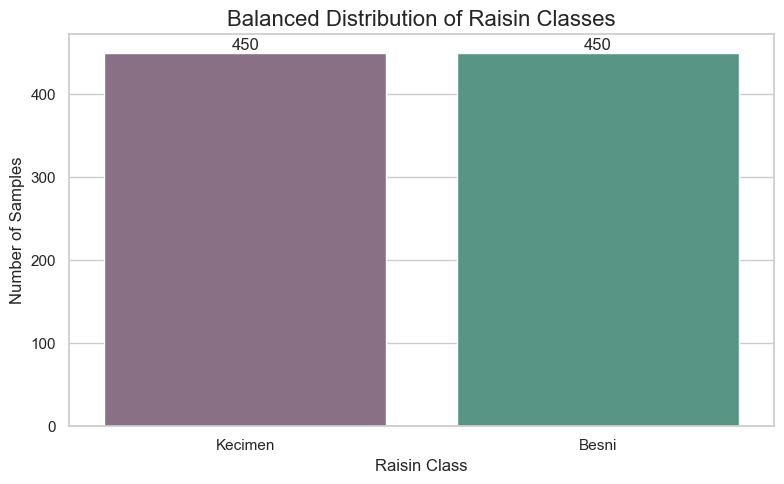

In [6]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=class_balance,
    x="Class",
    y="Count",
    hue="Class",
    palette=["#8E6C88", "#4E9F8A"],
    legend=False
)

plt.title("Balanced Distribution of Raisin Classes")
plt.xlabel("Raisin Class")
plt.ylabel("Number of Samples")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

## Main EDA Insights

The exploratory data analysis showed that several physical measurements differ between Kecimen and Besni raisins.

The most important visual insights were:

- The dataset has no missing values.
- The two classes are perfectly balanced.
- Size-related features such as `Area`, `ConvexArea`, `Perimeter` and `MajorAxisLength` are strongly correlated.
- The pairplot showed that the classes are partly separable based on size and shape.
- The correlation heatmap showed strong relationships between several numerical features.

These findings suggested that machine learning models should be able to learn patterns that separate the two raisin classes.

## Model Comparison

We trained and evaluated several supervised machine learning models:

1. Decision Tree  
2. Random Forest Baseline  
3. Tuned Random Forest  
4. XGBoost Baseline  
5. Tuned XGBoost  

All models used the same train/test split:

- `test_size=0.2`
- `random_state=42`
- `stratify=y`

This made the results comparable.

In [7]:
model_results = pd.DataFrame({
    "Model": [
        "Decision Tree",
        "Random Forest Baseline",
        "Tuned Random Forest",
        "XGBoost Baseline",
        "Tuned XGBoost"
    ],
    "Accuracy": [
        0.8444,
        0.8667,
        0.8722,
        0.8560,
        0.8500
    ]
})

model_results

,Model,Accuracy
0,Decision Tree,0.8444
1,Random Forest Baseline,0.8667
2,Tuned Random Forest,0.8722
3,XGBoost Baseline,0.8560
4,Tuned XGBoost,0.8500


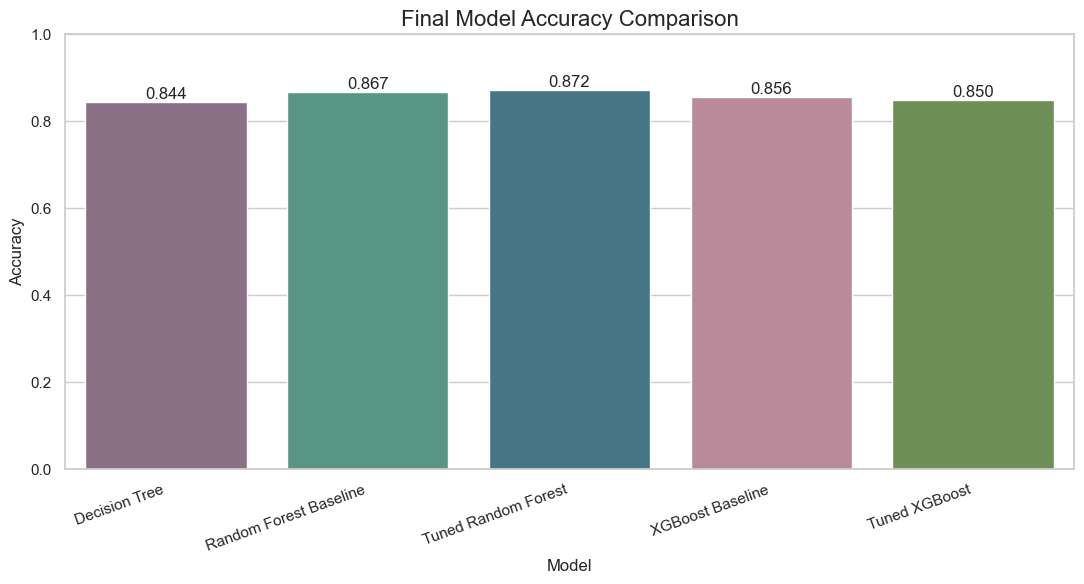

In [8]:
plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=model_results,
    x="Model",
    y="Accuracy",
    hue="Model",
    palette=["#8E6C88", "#4E9F8A", "#3B7A8F", "#C08497", "#6A994E"],
    legend=False
)

plt.title("Final Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f")

plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## Best Model

The best performing model was the Tuned Random Forest, with an accuracy of approximately 87.2%.

This model performed slightly better than the Random Forest baseline and better than both XGBoost models.

The result shows that Random Forest was the strongest model for this dataset. It also shows that a more advanced model, such as XGBoost, does not always guarantee better performance.

In [9]:
best_model = model_results.sort_values(by="Accuracy", ascending=False).iloc[0]

best_model

Model       Tuned Random Forest
Accuracy                 0.8722
Name: 2, dtype: object

## Feature Importance Summary

The Feature Importance and Permutation Importance analysis showed that `Perimeter` was the most reliable and important feature.

Random Forest Feature Importance suggested that several size-related variables were important, including:

- Perimeter
- MajorAxisLength
- ConvexArea
- Area

However, Permutation Importance showed that `Perimeter` had the strongest direct effect on model performance.

This makes sense because the perimeter describes the outer boundary of the raisin and captures important information about both size and shape.

In [10]:
importance_summary = pd.DataFrame({
    "Insight": [
        "Most important feature",
        "Most important feature group",
        "Reason",
        "Important note"
    ],
    "Result": [
        "Perimeter",
        "Size and shape-related variables",
        "Perimeter captures information about the raisin's outer boundary",
        "Highly correlated features may share similar information"
    ]
})

importance_summary

,Insight,Result
0,Most important feature,Perimeter
1,Most important feature group,Size and shape-related variables
2,Reason,Perimeter captures information about the raisi...
3,Important note,Highly correlated features may share similar i...


## Data Story: Raisin Detective

Imagine a food company that needs to sort two types of raisins: Kecimen and Besni.

Manual sorting can be time-consuming and may lead to mistakes, especially when raisins look similar. By using machine learning, the company can build a system that automatically classifies raisins based on measurable physical properties.

In this project, our model acts like a small "Raisin Detective". It looks at the raisin's area, perimeter, axis lengths, convex area and shape-related measurements to decide whether the raisin is Kecimen or Besni.

The results show that machine learning can successfully classify the raisin type with around 87% accuracy. The most important measurement was `Perimeter`, which suggests that the outer shape and size of the raisin are especially useful for classification.

## Business Value

This type of model could be useful in food production and quality control.

A company could use a similar machine learning model to:

- Automate product sorting
- Reduce manual work
- Improve consistency in classification
- Reduce human error
- Support quality control processes
- Save time in production

Even though this project is based on a small dataset, it demonstrates how supervised machine learning can be used to support decision-making in real production environments.

## Final Conclusion

The Raisin Detective project shows that supervised machine learning can classify raisin types based on numerical shape and size measurements.

The dataset was clean, balanced and suitable for classification.  
The Decision Tree model gave a useful baseline, while Random Forest improved performance by combining many trees.  
Hyperparameter tuning improved Random Forest slightly, making it the best model in this project.

XGBoost was also tested, but it did not outperform Random Forest in this case.

The final best model was Tuned Random Forest with approximately 87.2% accuracy.

The most important feature was `Perimeter`, which means that the outer boundary and overall shape of the raisin played a key role in classification.

Overall, the project demonstrates a complete supervised machine learning workflow, from EDA to model comparison and business interpretation.